# VIIRS Reader Playground

Use this notebook to explore the current VIIRS reader and scene-prep workflow on a local `VNP09GA` or `VJ109GA` file.

This version demonstrates:
- LUT-aware raw-band selection
- prepared-scene creation on the 500 m analysis grid
- plain-text structured logging to a `.log` file


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import xarray as xr

search_roots = [Path.cwd(), *Path.cwd().parents]
repo_root = next(path for path in search_roots if (path / "spires").exists() and (path / "tests" / "data").exists())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from spires import configure_spires_file_logger
from spires.sensors.viirs import (
    open_viirs_surface_reflectance,
    parse_viirs_surface_reflectance_filename,
    prepare_viirs_scene_for_inversion,
)

sample_path = Path.home() / "Downloads" / "VJ109GA.A2026112.h08v05.002.2026113072313.h5"
lut_path = repo_root / "tests" / "data" / "lut_viirs_noaa20_i1_i2_i3_m2_m4_m8_m11_3um_dust_bandpass.mat"
log_path = repo_root / "examples" / "viirs_reader_playground.log"

logger = configure_spires_file_logger(log_path, logger_name="spires.examples.viirs", log_to_stdout=False)
scene = parse_viirs_surface_reflectance_filename(sample_path)

print(scene)
print(f"Repo root: {repo_root}")
print(f"LUT: {lut_path}")
print(f"Log file: {log_path}")


SceneMetadata(product='VJ109GA', platform='noaa20', tile='h08v05', acquisition_date='2026-04-22', collection='002', processing_timestamp='2026113072313', source_path='/Users/ropa5718/Downloads/VJ109GA.A2026112.h08v05.002.2026113072313.h5')
Repo root: /Users/ropa5718/Library/CloudStorage/OneDrive-UCB-O365/Codex/SpiPy_RLG/SpiPy
LUT: /Users/ropa5718/Library/CloudStorage/OneDrive-UCB-O365/Codex/SpiPy_RLG/SpiPy/tests/data/lut_viirs_noaa20_i1_i2_i3_m2_m4_m8_m11_3um_dust_bandpass.mat
Log file: /Users/ropa5718/Library/CloudStorage/OneDrive-UCB-O365/Codex/SpiPy_RLG/SpiPy/examples/viirs_reader_playground.log


In [2]:
# Open the raw VIIRS file, reading only the reflectance bands needed by the LUT.
raw_ds = open_viirs_surface_reflectance(sample_path, lut_file=lut_path, logger=logger)

print("Selected bands:", raw_ds.attrs["selected_bands"])
print("Band selection source:", raw_ds.attrs["band_selection_source"])
print("500 m bands loaded:", list(raw_ds.band_500m.values))
print("1 km bands loaded:", list(raw_ds.band_1km.values))
raw_ds


Selected bands: ['I1', 'I2', 'I3', 'M2', 'M4', 'M8', 'M11']
Band selection source: filename
500 m bands loaded: [np.str_('I1'), np.str_('I2'), np.str_('I3')]
1 km bands loaded: [np.str_('M2'), np.str_('M4'), np.str_('M8'), np.str_('M11')]


<xarray.Dataset> Size: 148MB
Dimensions:                (y_1km: 1200, x_1km: 1200, band_1km: 4,
                            y_500m: 2400, x_500m: 2400, band_500m: 3)
Coordinates:
  * y_1km                  (y_1km) float64 10kB 4.448e+06 ... 3.337e+06
  * x_1km                  (x_1km) float64 10kB -1.112e+07 ... -1.001e+07
  * band_1km               (band_1km) <U3 48B 'M2' 'M4' 'M8' 'M11'
  * y_500m                 (y_500m) float64 19kB 4.448e+06 ... 3.336e+06
  * x_500m                 (x_500m) float64 19kB -1.112e+07 ... -1.001e+07
  * band_500m              (band_500m) <U2 24B 'I1' 'I2' 'I3'
Data variables: (12/20)
    reflectance_1km        (y_1km, x_1km, band_1km) float32 23MB 0.1881 ... 0...
    reflectance_500m       (y_500m, x_500m, band_500m) float32 69MB 0.1805 .....
    solar_zenith           (y_1km, x_1km) float32 6MB 28.97 28.97 ... 20.17
    solar_azimuth          (y_1km, x_1km) float32 6MB -159.3 -159.3 ... -148.6
    sensor_zenith          (y_1km, x_1km) float32 6MB 28.99 28.92 ... 41.52
    sensor_azimuth         (y_1km, x_1km) float32 6MB 75.2 75.09 ... 76.95 76.96
    ...                     ...
    num_observations_1km   (y_1km, x_1km) int8 1MB 1 1 1 1 1 1 2 ... 1 1 1 1 1 1
    obscov_1km             (y_1km, x_1km) int8 1MB 16 37 35 24 ... 49 39 39 45
    orbit_pnt              (y_1km, x_1km) int8 1MB 1 1 1 1 1 1 1 ... 0 0 0 0 0 0
    iobs_res               (y_500m, x_500m) uint8 6MB 0 0 0 0 0 0 ... 0 0 0 0 0
    num_observations_500m  (y_500m, x_500m) int8 6MB 1 1 1 1 1 1 ... 1 1 1 1 1 1
    obscov_500m            (y_500m, x_500m) int8 6MB 39 56 53 32 ... 61 43 56 73
Attributes:
    product:                VJ109GA
    platform:               noaa20
    tile:                   h08v05
    acquisition_date:       2026-04-22
    collection:             002
    processing_timestamp:   2026113072313
    source_path:            /Users/ropa5718/Downloads/VJ109GA.A2026112.h08v05...
    selected_bands:         ['I1', 'I2', 'I3', 'M2', 'M4', 'M8', 'M11']
    band_selection_source:  filename
    lut_file:               /Users/ropa5718/Library/CloudStorage/OneDrive-UCB...

In [3]:
# Prepare the scene for inversion on the 500 m analysis grid.
prepared_ds = prepare_viirs_scene_for_inversion(sample_path, lut_file=lut_path, logger=logger)

print(prepared_ds.reflectance)
prepared_ds


<xarray.DataArray 'reflectance' (y: 2400, x: 2400, band: 7)> Size: 161MB
array([[[0.1805    , 0.17979999, 0.16579999, ..., 0.1607    ,
         0.1453    , 0.1512    ],
        [0.20099999, 0.2007    , 0.18169999, ..., 0.1607    ,
         0.1453    , 0.1512    ],
        [0.1724    , 0.1714    , 0.1515    , ..., 0.21319999,
         0.1997    , 0.20199999],
        ...,
        [0.12879999, 0.24659999, 0.2218    , ..., 0.0905    ,
         0.2368    , 0.1284    ],
        [0.145     , 0.2529    , 0.2589    , ..., 0.1099    ,
         0.2963    , 0.19      ],
        [0.1443    , 0.2465    , 0.2629    , ..., 0.1099    ,
         0.2963    , 0.19      ]],

       [[0.2304    , 0.2321    , 0.2316    , ..., 0.1607    ,
         0.1453    , 0.1512    ],
        [0.22549999, 0.22639999, 0.2228    , ..., 0.1607    ,
         0.1453    , 0.1512    ],
        [0.1989    , 0.1998    , 0.2057    , ..., 0.21319999,
         0.1997    , 0.20199999],
...
        [0.11409999, 0.17819999, 0.25439999,

<xarray.Dataset> Size: 426MB
Dimensions:                       (y: 2400, x: 2400, band: 7, qa_flag: 7)
Coordinates:
  * y                             (y) float64 19kB 4.448e+06 ... 3.336e+06
  * x                             (x) float64 19kB -1.112e+07 ... -1.001e+07
  * band                          (band) <U3 84B 'I1' 'I2' 'I3' ... 'M8' 'M11'
  * qa_flag                       (qa_flag) <U3 84B 'QF1' 'QF2' ... 'QF6' 'QF7'
Data variables: (12/29)
    reflectance                   (y, x, band) float32 161MB 0.1805 ... 0.2182
    solar_zenith                  (y, x) float32 23MB 28.97 28.97 ... 20.17
    solar_azimuth                 (y, x) float32 23MB -159.3 -159.3 ... -148.6
    sensor_zenith                 (y, x) float32 23MB 28.99 28.99 ... 41.52
    sensor_azimuth                (y, x) float32 23MB 75.2 75.2 ... 76.96 76.96
    qa_qf1                        (y, x) uint8 6MB 78 78 78 78 ... 66 66 66 66
    ...                            ...
    mask_low_observation_support  (y, x) bool 6MB False False ... False False
    mask_cloud                    (y, x) bool 6MB False False ... False False
    mask_cloud_shadow             (y, x) bool 6MB False False ... False False
    mask_snow                     (y, x) bool 6MB False False ... False False
    valid_inversion_mask          (y, x) bool 6MB True True True ... True True
    valid_r0_mask                 (y, x) bool 6MB True True True ... True True
Attributes:
    product:                VJ109GA
    platform:               noaa20
    tile:                   h08v05
    acquisition_date:       2026-04-22
    collection:             002
    processing_timestamp:   2026113072313
    source_path:            /Users/ropa5718/Downloads/VJ109GA.A2026112.h08v05...
    selected_bands:         ['I1', 'I2', 'I3', 'M2', 'M4', 'M8', 'M11']
    band_selection_source:  filename
    lut_file:               /Users/ropa5718/Library/CloudStorage/OneDrive-UCB...

In [4]:
# Inspect the key prepared-scene outputs.
print(prepared_ds.dims)
print(list(prepared_ds.data_vars))
print("Prepared reflectance bands:", list(prepared_ds.band.values))


FrozenMappingWarningOnValuesAccess({'y': 2400, 'x': 2400, 'band': 7, 'qa_flag': 7})
['reflectance', 'solar_zenith', 'solar_azimuth', 'sensor_zenith', 'sensor_azimuth', 'qa_qf1', 'qa_qf2', 'qa_qf3', 'qa_qf4', 'qa_qf5', 'qa_qf6', 'qa_qf7', 'land_water_mask', 'num_observations_1km', 'obscov_1km', 'orbit_pnt', 'iobs_res', 'num_observations_500m', 'obscov_500m', 'qa_raw_stack', 'mask_invalid_reflectance', 'mask_bad_geometry', 'mask_water', 'mask_low_observation_support', 'mask_cloud', 'mask_cloud_shadow', 'mask_snow', 'valid_inversion_mask', 'valid_r0_mask']
Prepared reflectance bands: [np.str_('I1'), np.str_('I2'), np.str_('I3'), np.str_('M2'), np.str_('M4'), np.str_('M8'), np.str_('M11')]


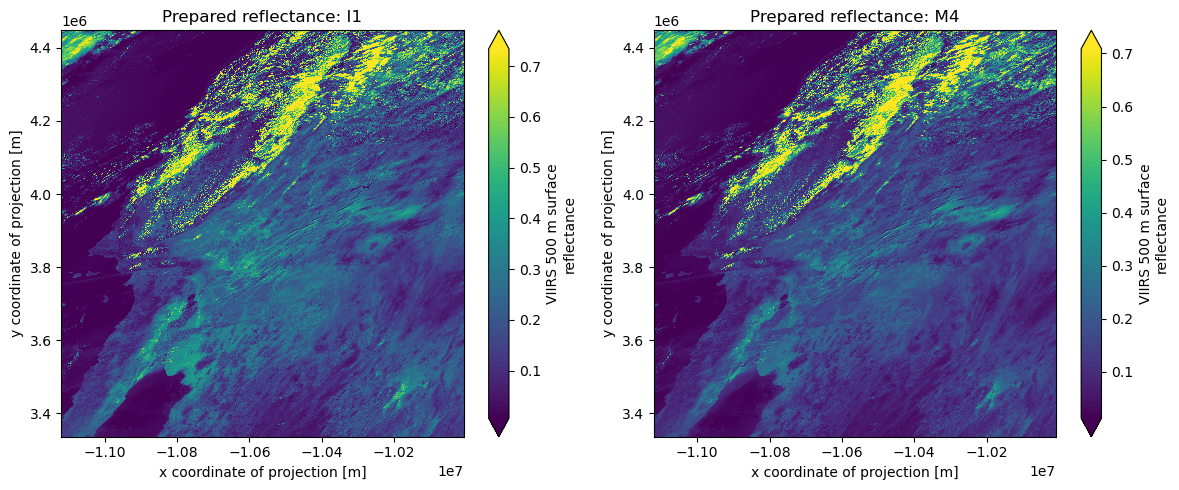

In [5]:
# Plot one 500 m imagery band and one 1 km moderate band after preparation.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

prepared_ds.reflectance.sel(band="I1").plot(ax=axes[0], robust=True)
axes[0].set_title("Prepared reflectance: I1")

prepared_ds.reflectance.sel(band="M4").plot(ax=axes[1], robust=True)
axes[1].set_title("Prepared reflectance: M4")

plt.tight_layout()


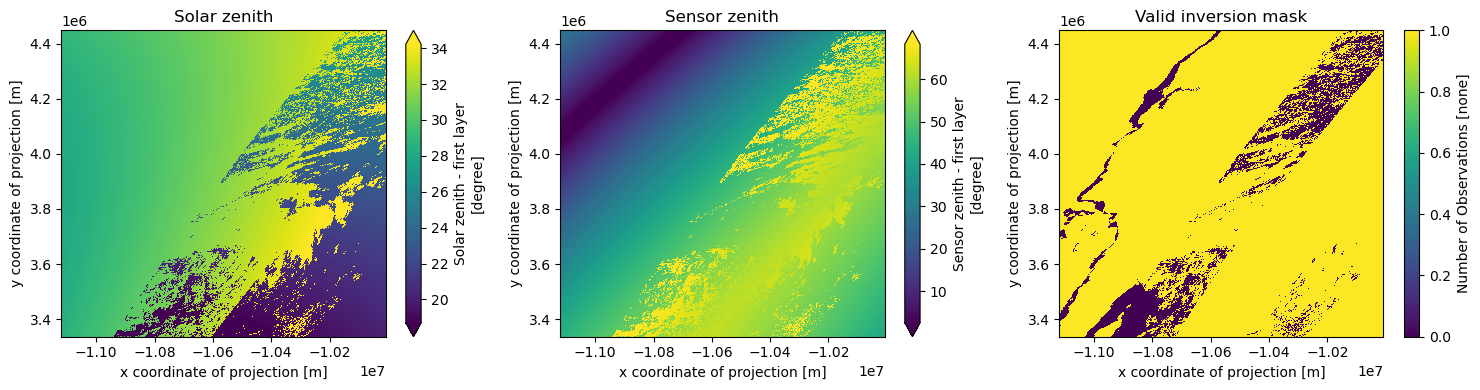

In [6]:
# Quick look at geometry and masks on the prepared 500 m grid.
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

prepared_ds.solar_zenith.plot(ax=axes[0], robust=True)
axes[0].set_title("Solar zenith")

prepared_ds.sensor_zenith.plot(ax=axes[1], robust=True)
axes[1].set_title("Sensor zenith")

prepared_ds.valid_inversion_mask.plot(ax=axes[2])
axes[2].set_title("Valid inversion mask")

plt.tight_layout()


In [7]:
# Preview the structured log lines written during the example run.
for line in log_path.read_text().splitlines()[-5:]:
    print(line)


2026-04-24 12:34:00,405 INFO spires.examples.viirs event="open_viirs_surface_reflectance" acquisition_date="2026-04-22" band_selection_source="filename" elapsed_seconds=0.551251 input_path="/Users/ropa5718/Downloads/VJ109GA.A2026112.h08v05.002.2026113072313.h5" lut_file="/Users/ropa5718/Library/CloudStorage/OneDrive-UCB-O365/Codex/SpiPy_RLG/SpiPy/tests/data/lut_viirs_noaa20_i1_i2_i3_m2_m4_m8_m11_3um_dust_bandpass.mat" platform="noaa20" product="VJ109GA" selected_1km_bands=["M2", "M4", "M8", "M11"] selected_500m_bands=["I1", "I2", "I3"] selected_bands=["I1", "I2", "I3", "M2", "M4", "M8", "M11"] tile="h08v05"
2026-04-24 12:34:03,349 INFO spires.examples.viirs event="open_viirs_surface_reflectance" acquisition_date="2026-04-22" band_selection_source="filename" elapsed_seconds=0.54277 input_path="/Users/ropa5718/Downloads/VJ109GA.A2026112.h08v05.002.2026113072313.h5" lut_file="/Users/ropa5718/Library/CloudStorage/OneDrive-UCB-O365/Codex/SpiPy_RLG/SpiPy/tests/data/lut_viirs_noaa20_i1_i2_i3_